# Interscale

## Setup

In [1]:
import scanpy as sc
import os
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns
import random
import torch
from pathlib import Path
import scvi

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` in

In [2]:
def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



set_full_reproducibility(42)

In [1]:
# INTERSCALE_DIR = ''
# print(INTERSCALE_DIR)
# os.chdir(INTERSCALE_DIR)

In [4]:
from joblib import load, dump

In [5]:
def aggregate_attention_matrix_optimized(attn_matrix, labels):
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    try:
        unique_labels = sorted(unique_labels, key=lambda x: int(x))
    except:
        unique_labels = sorted(unique_labels)
    
    n_labels = len(unique_labels)
    aggregated = np.zeros((n_labels, n_labels))
    
    label_indices = {label: np.where(labels == label)[0] for label in unique_labels}
    

    for i, row_label in enumerate(unique_labels):
        row_idxs = label_indices[row_label]
        row_data = attn_matrix[row_idxs, :]
        
        for j, col_label in enumerate(unique_labels):
            col_idxs = label_indices[col_label]
            block = row_data[:, col_idxs]
            aggregated[i, j] = np.nanmean(block)
            
    return pd.DataFrame(aggregated, index=unique_labels, columns=unique_labels)


def aggregate_attention_matrices(matrices_dict):

    if not matrices_dict:
        return None
    

    all_indices = set()
    all_columns = set()
    
    for _, matrix in matrices_dict.items():
        all_indices.update(matrix.index)
        all_columns.update(matrix.columns)
    
    all_indices = sorted(list(all_indices), key=lambda x: int(x) if str(x).isdigit() else x)
    all_columns = sorted(list(all_columns), key=lambda x: int(x) if str(x).isdigit() else x)

    sum_matrix = pd.DataFrame(0.0, index=all_indices, columns=all_columns)
    count_matrix = pd.DataFrame(0.0, index=all_indices, columns=all_columns)

    for _, matrix in matrices_dict.items():

        aligned = matrix.reindex(index=all_indices, columns=all_columns)
        valid_mask = aligned.notna()
        
        sum_matrix += aligned.fillna(0)
        count_matrix += valid_mask.astype(float)

    average_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    average_matrix.fillna(0, inplace=True)
    return average_matrix

## Prepare data

In [ ]:
adata=sc.read_h5ad('data/melton_jimenez_25/cosmx_pancreas_s1.h5ad')

In [7]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [8]:
adata.obs['batch']=adata.obs['fov'].astype('category')

In [9]:
sq.gr.spatial_neighbors(
	adata,
	radius=200,
	coord_type='generic',
	library_key = 'batch'
)
conn = adata.obsp['spatial_connectivities']

In [10]:
# Create a boolean mask for rows without NaN coordinates
valid_coords = ~np.isnan(adata.obsm["spatial"]).any(axis=1)

# Filter the AnnData object
adata = adata[valid_coords].copy()

# Verify the removal of NaN values
print(f"NaN values remaining: {np.isnan(adata.obsm['spatial']).sum()}")

NaN values remaining: 0


In [11]:
tissue_cell_number = adata.obs.groupby('batch').size()
print(f"Nr cells per sliding window: Min: {tissue_cell_number.min()}, Max: {tissue_cell_number.max()}, Avg: {tissue_cell_number.mean()}")

Nr cells per sliding window: Min: 2321, Max: 5583, Avg: 4557.217391304348


/beegfs/scratch/tmp/ipykernel_3322740/3598221288.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_cell_number = adata.obs.groupby('batch').size()


<Axes: xlabel='batch'>

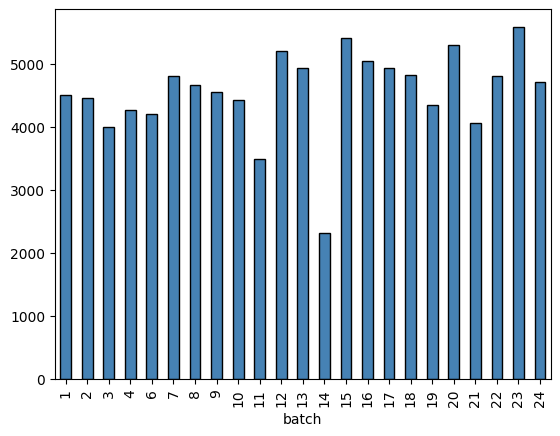

In [12]:

tissue_cell_number.plot(kind='bar', color='steelblue', edgecolor='black')

In [13]:
MAX_CELLS=3000

In [14]:
batches_over_4k = tissue_cell_number[tissue_cell_number > MAX_CELLS]
print(batches_over_4k)

batch
1     4499
2     4450
3     4000
4     4274
6     4206
7     4807
8     4657
9     4547
10    4423
11    3493
12    5208
13    4935
15    5401
16    5045
17    4929
18    4819
19    4342
20    5299
21    4053
22    4810
23    5583
24    4715
dtype: int64


In [15]:
sq.tl.sliding_window(
    adata=adata,
    library_key="batch",  # to stratify by sample
    window_size=2100,
    overlap=0,
    copy=False,  # we modify in place
)

In [16]:
window_size = adata.obs.groupby('sliding_window_assignment').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 5, Max: 1436, Avg: 759.536231884058


/beegfs/scratch/tmp/ipykernel_3322740/3351268401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_size = adata.obs.groupby('sliding_window_assignment').size()


In [17]:
## Create SPlit
proportions = {'train': 0.7, 'val': 0.2, 'test': 0.1}
splits = list(proportions.keys())
weights = list(proportions.values())

def stratified_split(group_df, splits, weights):
    n_rows = len(group_df)

    split_labels = np.random.choice(splits, size=n_rows, p=weights)

    return pd.Series(split_labels, index=group_df.index)


adata.obs['split'] = adata.obs.groupby('batch', group_keys=False).apply(
    lambda x: stratified_split(x, splits, weights)
)

/beegfs/scratch/tmp/ipykernel_3322740/570915561.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs['split'] = adata.obs.groupby('batch', group_keys=False).apply(
/beegfs/scratch/tmp/ipykernel_3322740/570915561.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adata.obs['split'] = adata.obs.groupby('batch', group_keys=False).apply(


### Compute SCVI latent space

In [ ]:
scvi.model.SCVI.setup_anndata(adata,batch_key='batch',categorical_covariate_keys=['condition'])
scvi_model = scvi.model.SCVI(
                        adata, 
                        n_latent=16, 
                        n_layers=2)
scvi_model.train(max_epochs=100, enable_progress_bar=False)

latent_repr = scvi_model.get_latent_representation()
adata.obsm['scvi_latent'] = latent_repr

### Compute CellCharter embeddings

In [ ]:
import cellcharter as cc

In [ ]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='scvi_latent', out_key='X_cellcharter', sample_key='sample')

100%|██████████| 17/17 [00:04<00:00,  3.70it/s]


In [ ]:

sc.pp.neighbors(adata, use_rep='X_cellcharter', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.2, key_added='leiden_cellcharter')

### Compute Banksy embeddings

In [ ]:
from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam


Median distance to closest cell = 44.9221548904324

---- Ran median_dist_to_nearest_neighbour in 0.02 s ----

---- Ran generate_spatial_distance_graph in 0.03 s ----

---- Ran row_normalize in 0.08 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.60 s ----

---- Ran generate_spatial_distance_graph in 0.05 s ----

---- Ran theta_from_spatial_graph in 0.20 s ----

---- Ran row_normalize in 0.09 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.83 s ----

----- Plotting theta Graph -----

Median distance to closest cell = 47.16990566028302

---- Ran median_dist_to_nearest_neighbour in 0.02 s ----

---- Ran generate_spatial_distance_graph in 0.03 s ----

---- Ran row_normalize in 0.01 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.31 s ----

---- Ran generate_spatial_distance_graph in 0.02 s ----

---- Ran theta_from_spatial_graph in 0.05 s ----

---- Ran row_normalize in 0.01 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.23 s ----

----- Plotting t

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/banksy_utils/plot_utils.py:188: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=options['figsize'])



Median distance to closest cell = 42.04759208325728

---- Ran median_dist_to_nearest_neighbour in 0.01 s ----

---- Ran generate_spatial_distance_graph in 0.02 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.21 s ----

---- Ran generate_spatial_distance_graph in 0.04 s ----

---- Ran theta_from_spatial_graph in 0.06 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.30 s ----

----- Plotting theta Graph -----

Median distance to closest cell = 43.174066289845804

---- Ran median_dist_to_nearest_neighbour in 0.01 s ----

---- Ran generate_spatial_distance_graph in 0.02 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.17 s ----

---- Ran generate_spatial_distance_graph in 0.03 s ----

---- Ran theta_from_spatial_graph in 0.06 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.26 s ----

----- Plotting

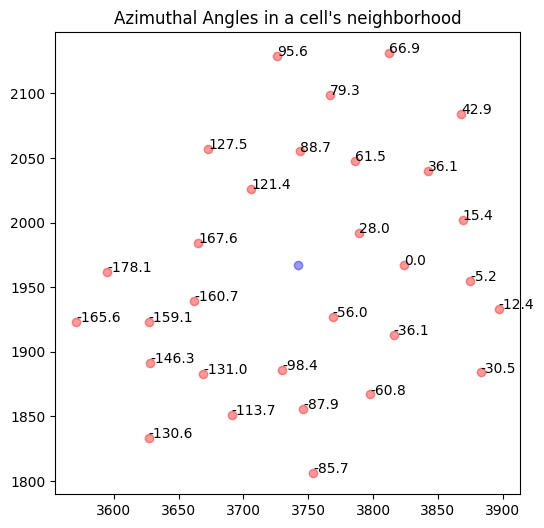

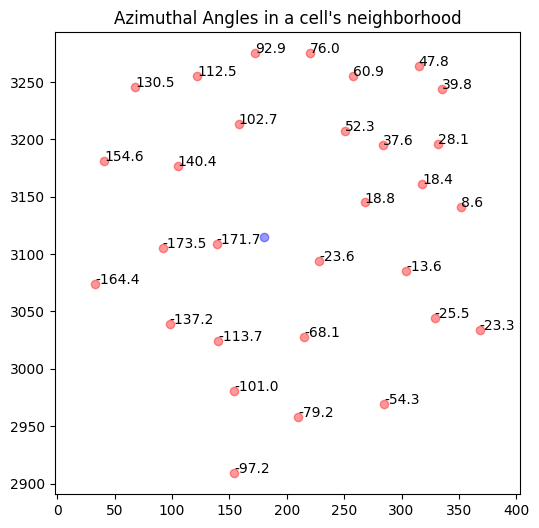

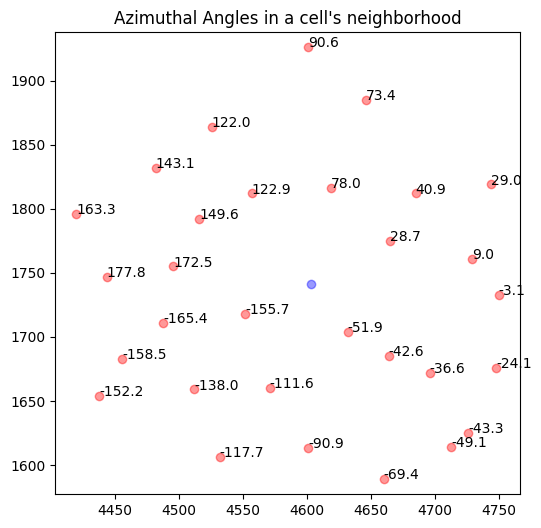

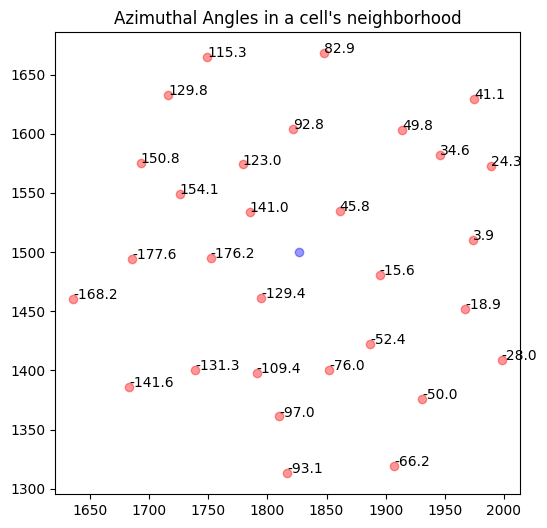

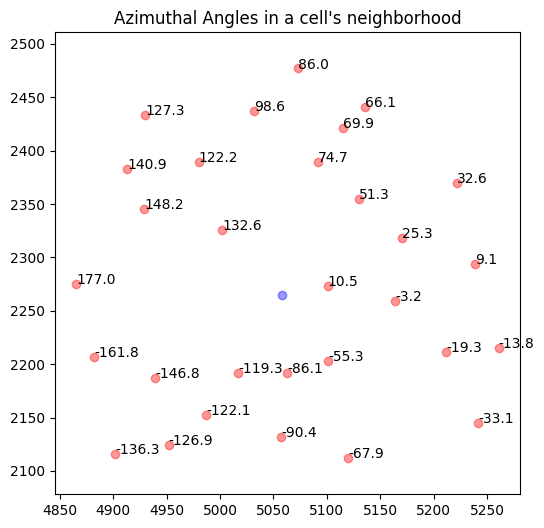

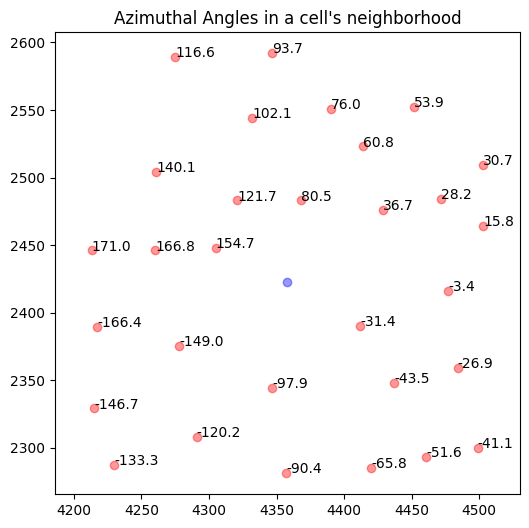

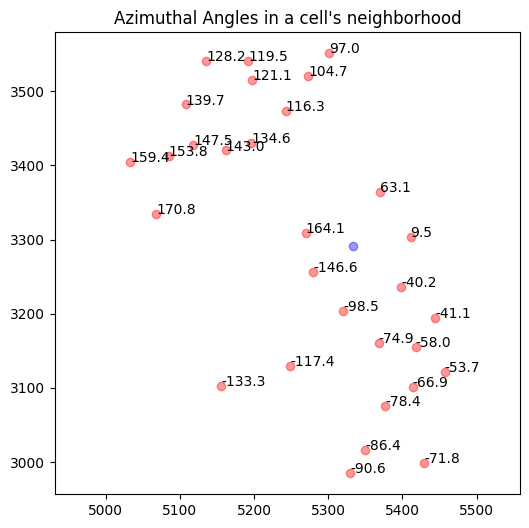

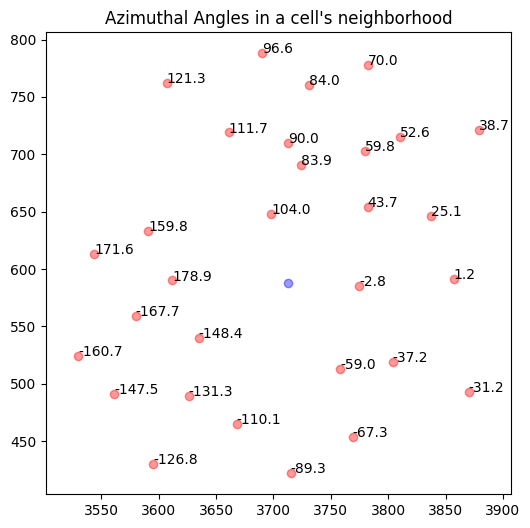

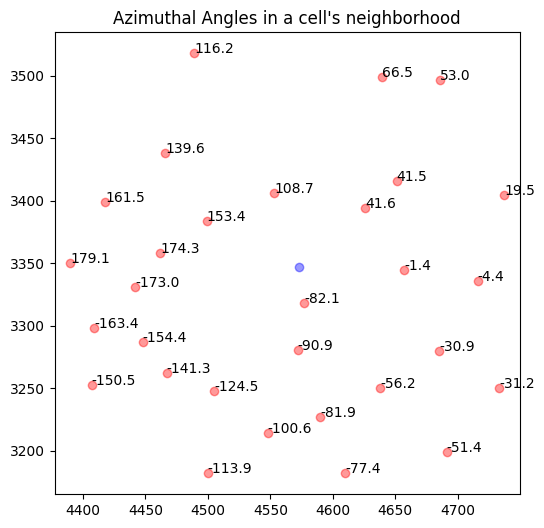

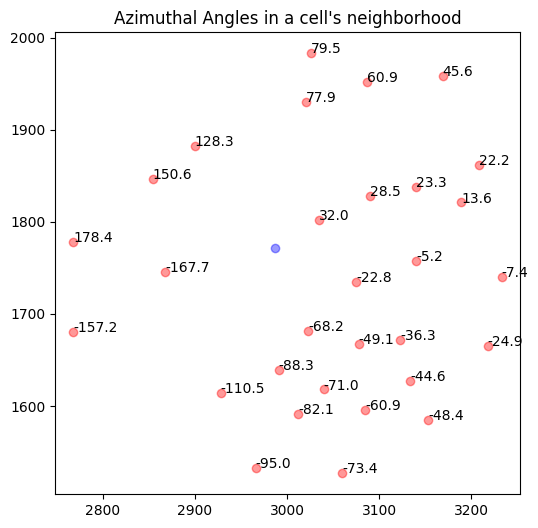

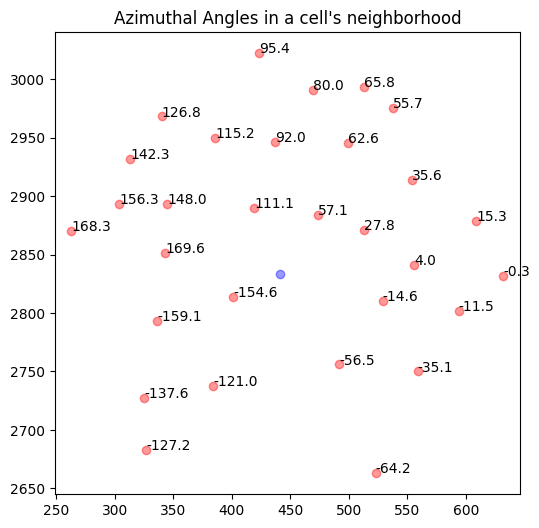

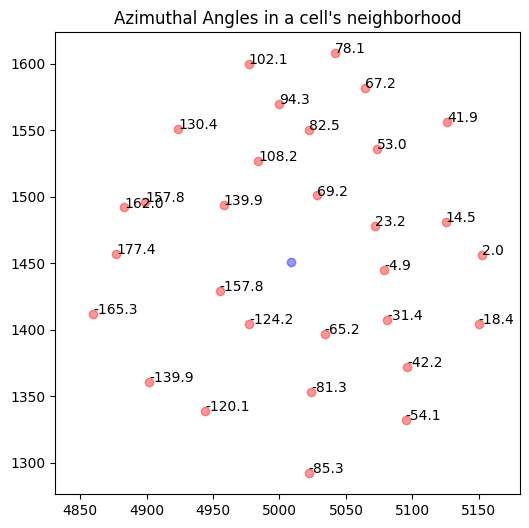

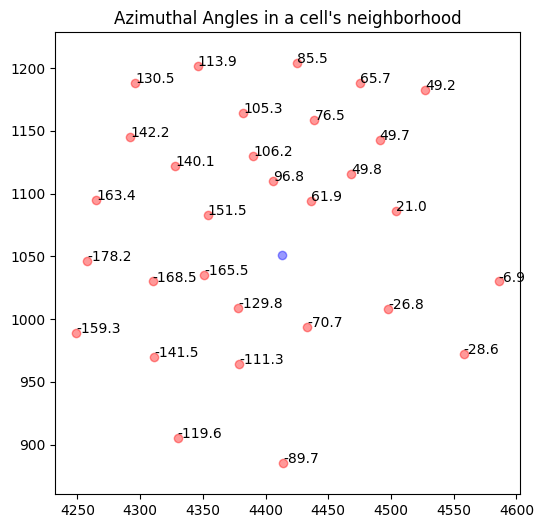

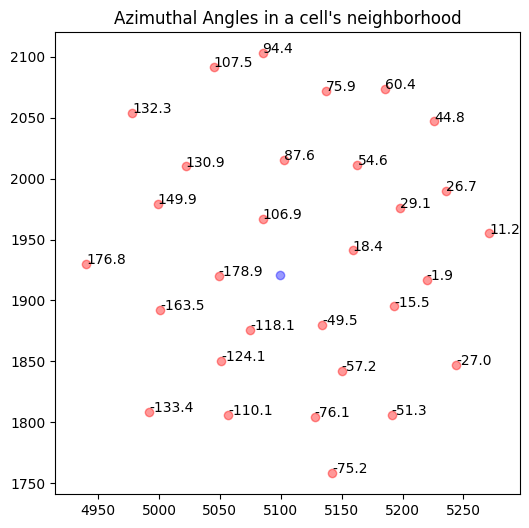

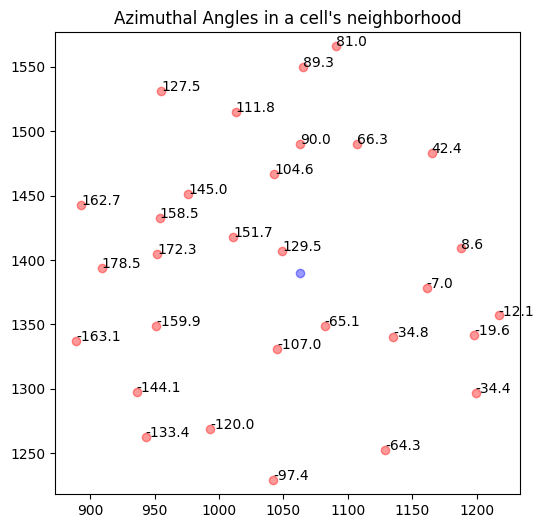

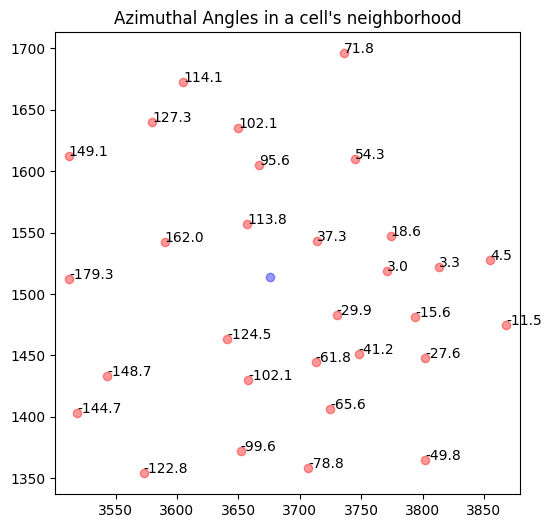

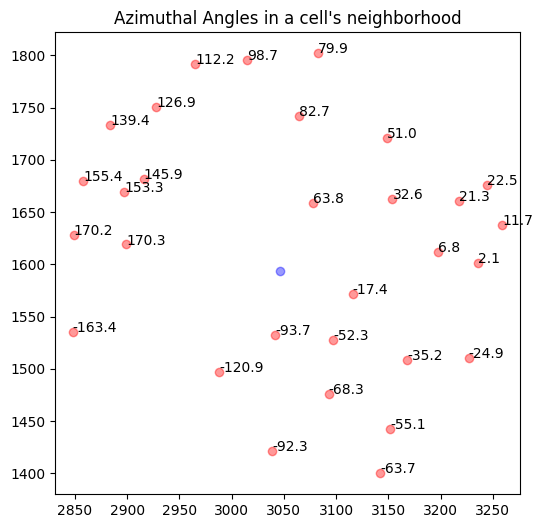

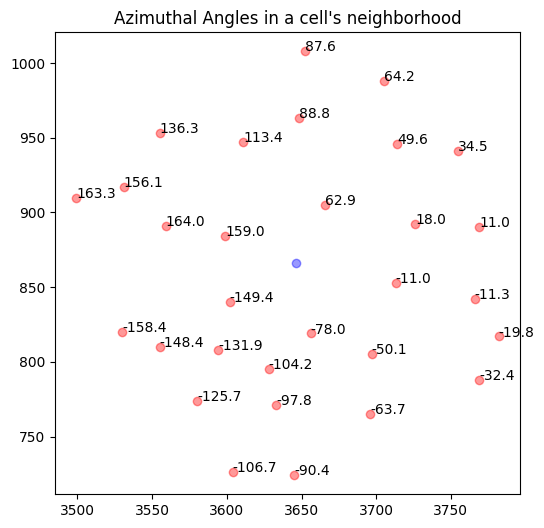

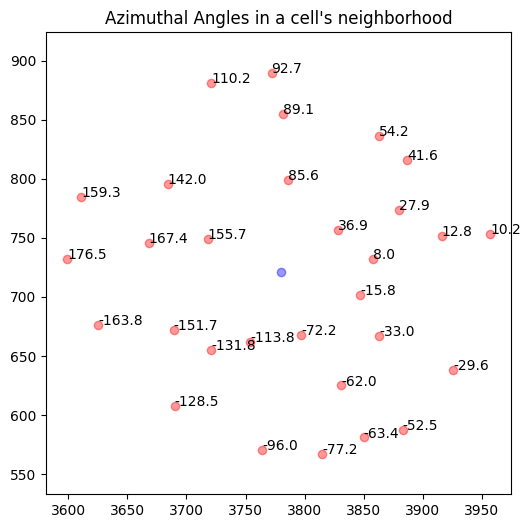

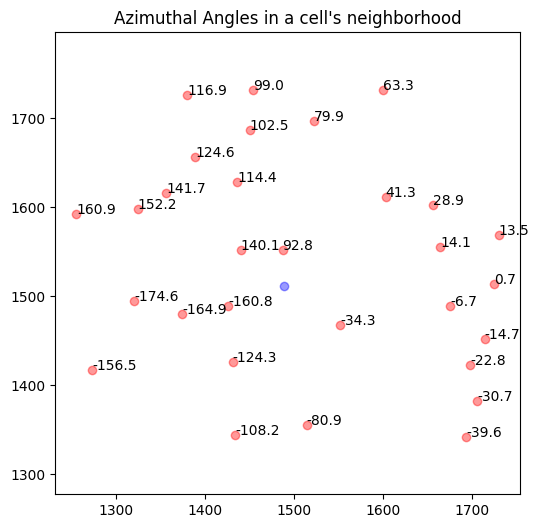

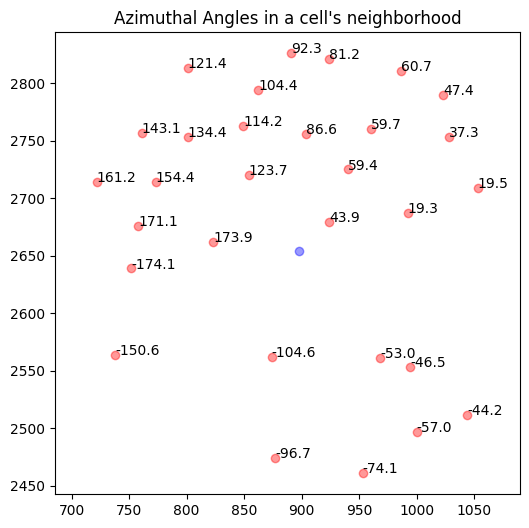

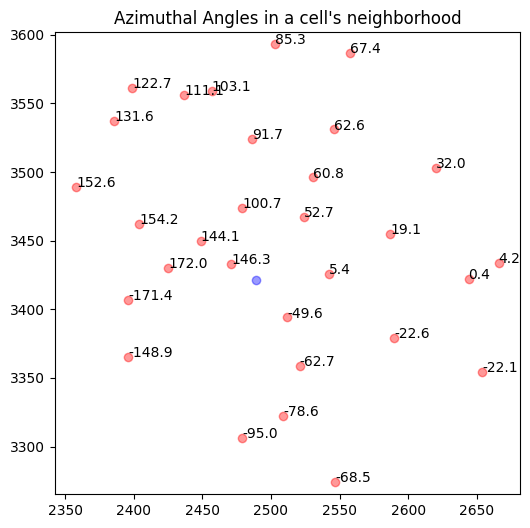

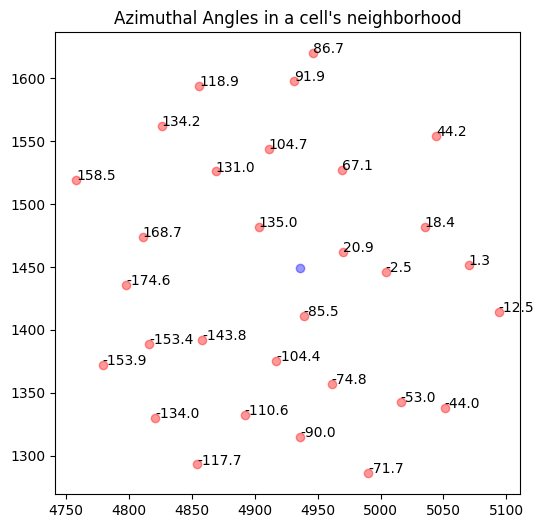

In [ ]:
from scipy.sparse import block_diag


if "x" not in adata.obs or "y" not in adata.obs:
    adata.obs["x"] = adata.obsm["spatial"][:, 0]
    adata.obs["y"] = adata.obsm["spatial"][:, 1]
coord_keys = ('x', 'y', 'spatial')
slice_col = "batch"

adata = adata[adata.obs.sort_values(by=slice_col).index].copy()

banksy_per_slice = {}
unique_slices = adata.obs[slice_col].unique()

for slice_id in adata.obs[slice_col].unique():
    sub_adata = adata[adata.obs[slice_col] == slice_id].copy()

    banksy_per_slice[slice_id] = initialize_banksy(
        sub_adata,
        coord_keys=coord_keys,
        num_neighbours=15,
        nbr_weight_decay="scaled_gaussian",
        plt_edge_hist=False,
        plt_nbr_weights=False,
    )


first_slice = unique_slices[0]
weight_decay_key = list(banksy_per_slice[first_slice].keys())[0]

num_weights = len(banksy_per_slice[first_slice][weight_decay_key]["weights"])
block_weights = []

for w_idx in range(num_weights):
    slice_mats = [
        banksy_per_slice[s_id][weight_decay_key]["weights"][w_idx]
        for s_id in unique_slices
    ]

    combined_mat = block_diag(slice_mats, format="csr")
    block_weights.append(combined_mat)


global_banksy_dict = {
    weight_decay_key: {
        "weights": block_weights,
        "distances": None, 
    }
}



In [ ]:

first_slice = unique_slices[0]
decay_key = "scaled_gaussian"


weight_dict_keys = banksy_per_slice[first_slice][decay_key]["weights"].keys()

global_weights_dict = {}

for w_key in weight_dict_keys:

    slice_mats = [
        banksy_per_slice[s_id][decay_key]["weights"][w_key]
        for s_id in unique_slices
    ]

    global_weights_dict[w_key] = block_diag(slice_mats, format="csr")


global_banksy_dict = {decay_key: {"weights": global_weights_dict}}

Runtime Jul-21-2026-18-02

979 genes to be analysed:
Gene List:
Index(['AATK', 'ABL1', 'ABL2', 'ACE', 'ACE2', 'ACKR1', 'ACKR3', 'ACKR4',
       'ACTA2', 'ACTG2',
       ...
       'NegPrb13', 'NegPrb14', 'NegPrb15', 'NegPrb16', 'NegPrb18', 'NegPrb19',
       'NegPrb20', 'NegPrb21', 'NegPrb22', 'NegPrb23'],
      dtype='object', length=979)

Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1572240 stored elements and shape (104816, 104816)>, 1: <Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 3144480 stored elements and shape (104816, 104816)>}}

Nbr matrix | Mean: 0.06 | Std: 0.2
Size of Nbr | Shape: (104816, 979)
Top 3 entries of Nbr Mat:

[[0.         0.03261613 0.22388496]
 [0.09936999 0.03457156 0.06433188]
 [0.10160757 0.         0.07364574]]

AGF matrix | Mean: 0.03 | Std: 0.05
Size of AGF mat (m = 1) | Shape: (104816, 979)
Top entries of AGF:


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/banksy/cluster_methods.py:350: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for key in adata_temp.obsm_keys():



Nearest-neighbour weighted graph (dtype: float64, shape: (104816, 104816)) has 5240800 nonzero entries.
---- Ran find_nn in 538.86 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (104816, 104816)) has 5240800 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 199516774 to 5195628.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (104816, 104816)) has 4074554 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (104816, 104816)) has 4074554 nonzero entries.

sNN graph data:
[ 7  9 10 ...  6  5  5]

---- Ran shared_nn in 12.38 s ----


-- Multiplying sNN connectivity by weights --


shared NN with distance-based weights graph (dtype: float64, shape: (104816, 104816)) has 4074554 nonzero entries.
shared NN weighted graph data: [0.22497176 0.22757646 0.227719   ... 0.22784249 0.2278878  0.23767648]

Converting graph (dtype

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/banksy/cluster_methods.py:350: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for key in adata_temp.obsm_keys():



Nearest-neighbour weighted graph (dtype: float64, shape: (104816, 104816)) has 5240800 nonzero entries.
---- Ran find_nn in 639.30 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (104816, 104816)) has 5240800 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 226269248 to 5175609.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (104816, 104816)) has 3764805 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (104816, 104816)) has 3764805 nonzero entries.

sNN graph data:
[6 8 9 ... 6 5 6]

---- Ran shared_nn in 15.58 s ----


-- Multiplying sNN connectivity by weights --


shared NN with distance-based weights graph (dtype: float64, shape: (104816, 104816)) has 3764805 nonzero entries.
shared NN weighted graph data: [0.25864135 0.26021487 0.26069972 ... 0.23488438 0.24140335 0.25334301]

Converting graph (dtype: floa

,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata
nonspatial_pc20_nc0.00_r0.50,nonspatial,0.0,20,0.5,9,"Label object:\nNumber of labels: 9, number of ...",[[[View of AnnData object with n_obs × n_vars ...
nonspatial_pc20_nc0.00_r1.00,nonspatial,0.0,20,1.0,14,"Label object:\nNumber of labels: 14, number of...",[[[View of AnnData object with n_obs × n_vars ...
scaled_gaussian_pc20_nc0.20_r0.50,scaled_gaussian,0.2,20,0.5,9,"Label object:\nNumber of labels: 9, number of ...",[[[View of AnnData object with n_obs × n_vars ...
scaled_gaussian_pc20_nc0.20_r1.00,scaled_gaussian,0.2,20,1.0,13,"Label object:\nNumber of labels: 13, number of...",[[[View of AnnData object with n_obs × n_vars ...


Anndata AxisArrays with keys: reduced_pc_20


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/banksy/run_banksy.py:141: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(adata_temp.obs[coord_keys[0]].values,


Anndata AxisArrays with keys: reduced_pc_20
Anndata AxisArrays with keys: reduced_pc_20
Anndata AxisArrays with keys: reduced_pc_20


['banksy_output/rr.h5ad']

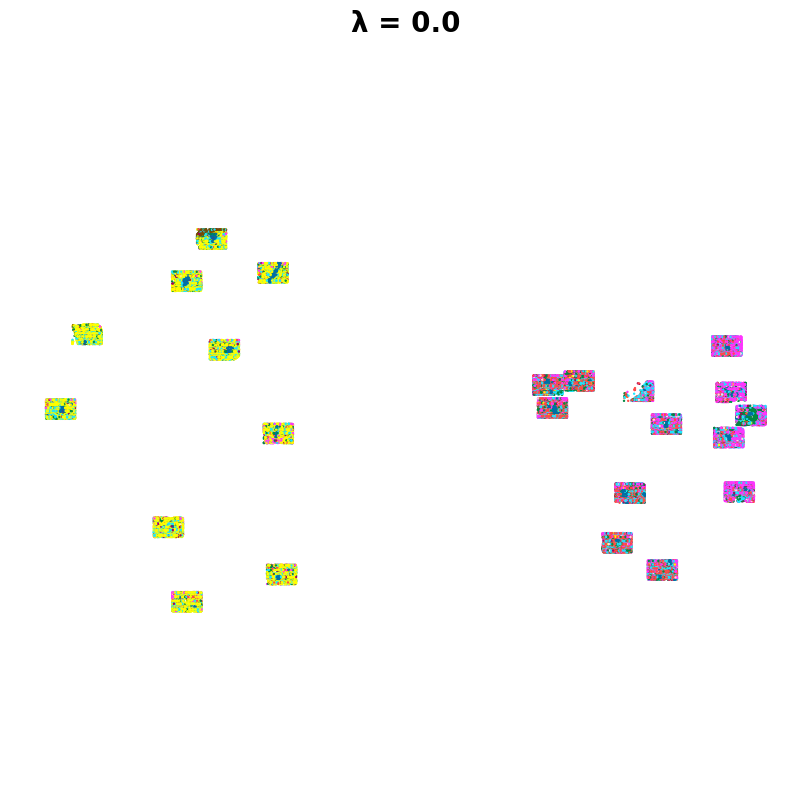

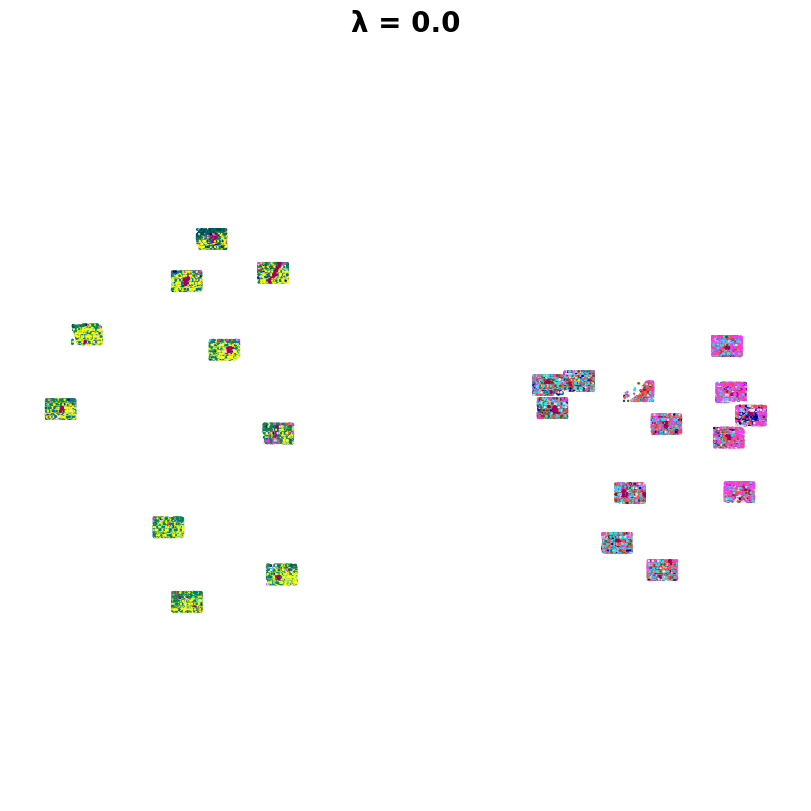

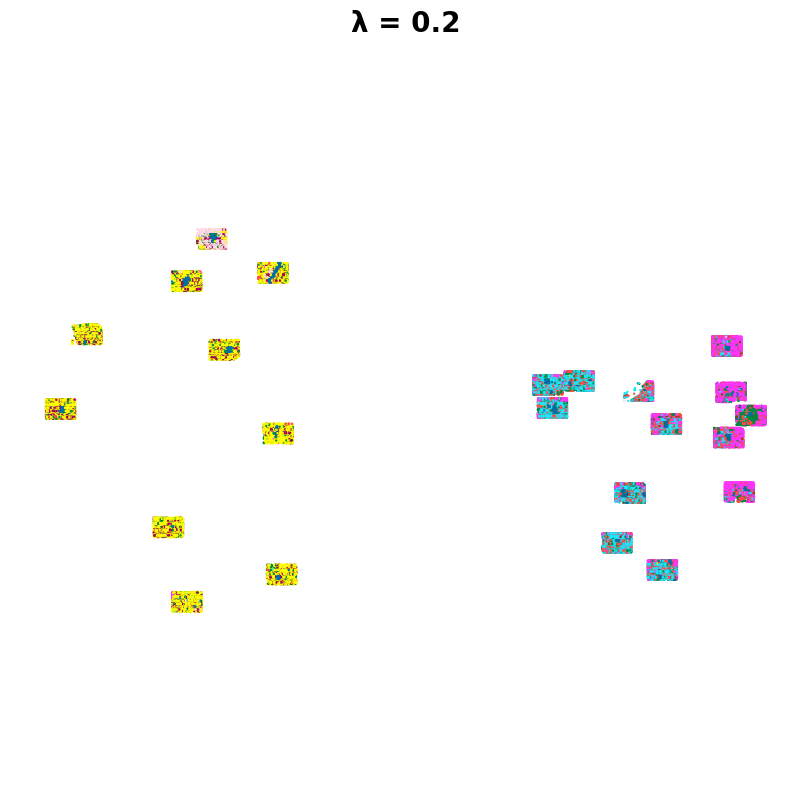

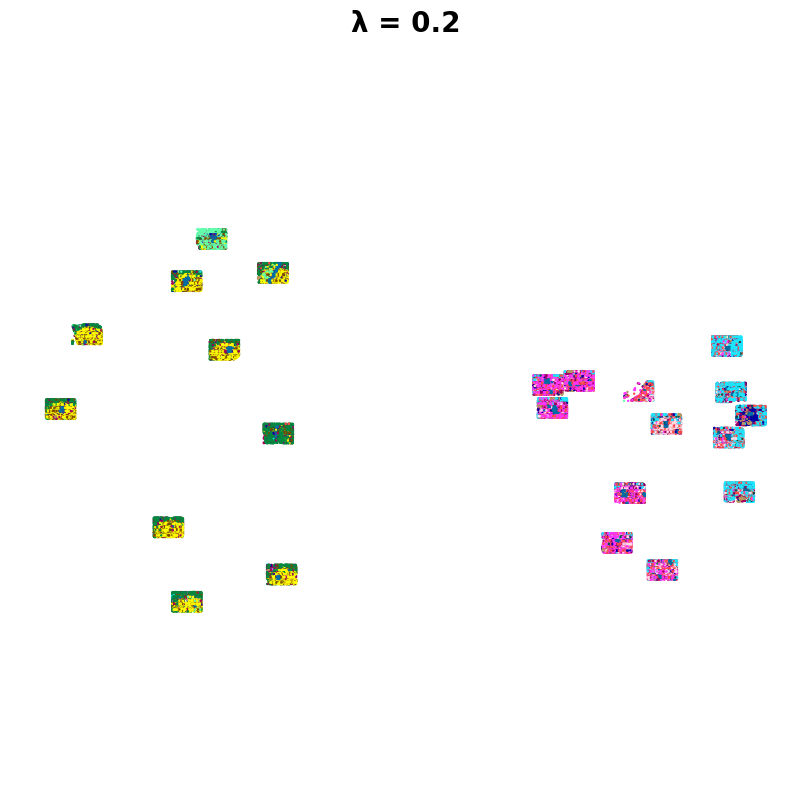

In [ ]:
from joblib import dump

color_list = list(sc.pl.palettes.default_102)

results_df = run_banksy_multiparam(
    adata,
    global_banksy_dict,
    lambda_list=[0.2],
    resolutions=[0.5, 1.0],
    color_list=color_list,
    max_m=1,
    filepath="./banksy_output",
    key=("x", "y"),
    annotation_key=None
)



In [ ]:
adata.obs['banksy_labels']=results_df['labels']['scaled_gaussian_pc20_nc0.20_r0.50'].dense.astype(str)

In [ ]:
adata.obsm['X_banksy']=results_df['adata']['scaled_gaussian_pc20_nc0.20_r0.50'].obsm['reduced_pc_20']

### Compute STAGATE embeddings

In [ ]:
import STAGATE_pyG as STAGATE

In [ ]:
if "x" not in adata.obs or "y" not in adata.obs:
    adata.obs["x"] = adata.obsm["spatial"][:, 0]
    adata.obs["y"] = adata.obsm["spatial"][:, 1]

slice_col = "batch"

In [ ]:
for slice_id in adata.obs[slice_col].unique():
    sub_idx = adata.obs[slice_col] == slice_id
    sub_adata = adata[sub_idx].copy()
    
    # Calculate spatial network for the individual sample (k-NN or radius-based)
    STAGATE.Cal_Spatial_Net(sub_adata, k_cutoff=15, model='KNN')
    
    # Store network edges
    if 'Spatial_Net' not in adata.uns:
        adata.uns['Spatial_Net'] = sub_adata.uns['Spatial_Net'].copy()
    else:
        # Re-index node indices relative to global AnnData positioning
        slice_net = sub_adata.uns['Spatial_Net'].copy()
        
        # Map local integer indices back to absolute slice positions
        # (handy if Cal_Spatial_Net returns integer offset rows)
        adata.uns['Spatial_Net'] = pd.concat(
            [adata.uns['Spatial_Net'], slice_net], 
            ignore_index=True
        )

------Calculating spatial graph...
The graph contains 67485 edges, 4499 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 66750 edges, 4450 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 60000 edges, 4000 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 64110 edges, 4274 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 63090 edges, 4206 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 72105 edges, 4807 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 69855 edges, 4657 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 68205 edges, 4547 cells.
15.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 66

In [ ]:
STAGATE.train_STAGATE(adata, hidden_dims=[512, 64])

Size of Input:  (104816, 979)


100%|██████████| 1000/1000 [03:24<00:00,  4.90it/s]


AnnData object with n_obs × n_vars = 104816 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'niche_label', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window', 'batch', 'sliding_window_assignment', 'split', '_scvi_batch', '_scvi_labels', 'banksy_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_coarse_colors', 'sliding_window_1_colors', 'sliding_window_2_colors'

In [ ]:
adata.obsm['X_stagate']=adata.obsm['STAGATE'].copy()

In [ ]:
sc.pp.neighbors(adata, use_rep='X_stagate', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.2, key_added='leiden_stagate')

### Save Dataset

In [ ]:
adata.write_h5ad('data/melton_jimenez_25/adata_cosmx_IS.h5ad')

## Dual Local (GCN) + Global (Transformer)

### Train

In [19]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assign

In [ ]:
cfg_path = 'config_files/melton_jimenez_25/InterScale_Cosmx_Nrec_Modular.yaml'
model_type = 'CombinedModel'

In [21]:
cfg = load_config(cfg_path)
print(cfg)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)

dataset:
  batch_size: 3
  description: 
  group_label: condition
  h5ad_data: data/cosmx/adata_cosmx_IS.h5ad
  layer_key: log1p_norm
  name: cosmxnrec
  num_classes: -1
  num_features: -1
  pct_mask_nodes: 0.3
  prediction_level: node
  prediction_obs: None
  prediction_task: regression
  sample_key: ['sliding_window_assignment']
  segmentation_robustness: [0.2, 0.5]
  spatial_neigbors_kwargs:
    coord_type: generic
    library_key: sliding_window_assignment
    n_neighs: 6
    radius: 200
  split_key: split
  stratify_group: None
  test_size: 0.1
  train_size: 0.7
  val_size: 0.2
model:
  decoder:
    dropout_decoder: 0.1
    dual_decoder: True
    hidden_dims: [256, 128]
    type: linear
  global_component:
    latent_obsm_key: None
    name: self-attn-transformer
    parameters:
      activation_func: relu
      dim_feedforward: 256
      dropout_global: 0.1
      long_range_attention: False
      max_seq_len: 1436
      n_heads: 4
      num_layers: 2
      type_gex_embedding: Non

In [22]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [23]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [24]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [25]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.CombinedModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [26]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [27]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [28]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [30]:
model= interscale.model.CombinedModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/dual_cosmxnrec_regr_node_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [31]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


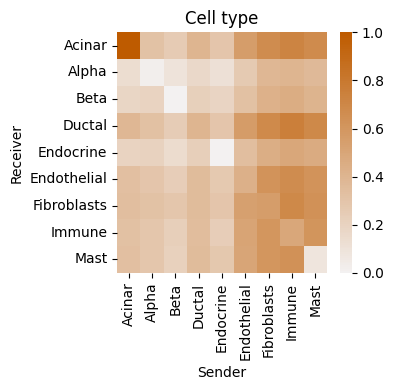

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['cell_type_coarse']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sliding_window_assignment']):

		mask = result.obs['sliding_window_assignment'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'Cell type')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/cosmx_DinterscaleGCN_cell_type_coarse.csv')



plt.tight_layout()

#### Compare Local embeddings domain identification with Banksy, STAGATE and CellCharter

In [ ]:
sc.pp.neighbors(result, use_rep='combined_local_emb', n_neighbors=15)
sc.tl.leiden(result, resolution=0.2, key_added='leiden_localEmb')

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd


cluster_cols = ['leiden_localEmb', 'leiden_stagate', 'banksy_labels','leiden_cellcharter']
#target_col = 'cell_type_coarse' 
target_col = 'niche_label' 

results_cross = []
for col1 in cluster_cols:
    for col2 in cluster_cols:
        if col1 != col2:
            nmi = normalized_mutual_info_score(result.obs[col1], result.obs[col2])
            ari = adjusted_rand_score(result.obs[col1], result.obs[col2])
            results_cross.append({'Method_A': col1, 'Method_B': col2, 'NMI': nmi, 'ARI': ari})

df_cross = pd.DataFrame(results_cross)
print(df_cross)


results_gt = []
if target_col in result.obs.columns:
    for col in cluster_cols:
        nmi = normalized_mutual_info_score(result.obs[target_col], result.obs[col])
        ari = adjusted_rand_score(result.obs[target_col], result.obs[col])
        results_gt.append({'Clustering': col, 'NMI_vs_GT': nmi, 'ARI_vs_GT': ari})
    
    df_gt = pd.DataFrame(results_gt)


--- Confronto tra clustering ---
              Method_A            Method_B       NMI       ARI
0      leiden_localEmb      leiden_stagate  0.585092  0.565381
1      leiden_localEmb       banksy_labels  0.468869  0.398244
2      leiden_localEmb  leiden_cellcharter  0.297480  0.128326
3       leiden_stagate     leiden_localEmb  0.585092  0.565381
4       leiden_stagate       banksy_labels  0.459921  0.371888
5       leiden_stagate  leiden_cellcharter  0.325804  0.169561
6        banksy_labels     leiden_localEmb  0.468869  0.398244
7        banksy_labels      leiden_stagate  0.459921  0.371888
8        banksy_labels  leiden_cellcharter  0.233782  0.068347
9   leiden_cellcharter     leiden_localEmb  0.297480  0.128326
10  leiden_cellcharter      leiden_stagate  0.325804  0.169561
11  leiden_cellcharter       banksy_labels  0.233782  0.068347

--- Confronto rispetto a cell_type_coarse ---
           Clustering  NMI_vs_GT  ARI_vs_GT
0     leiden_localEmb   0.188841   0.108334
1      leiden

## PCA + Global (Transformer)

### Train

In [69]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [ ]:
cfg_path = 'config_files/melton_jimenez_25/InterScale_Cosmx_Nrec_globalPCA.yaml'
model_type = 'GlobalModel'

In [71]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [72]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [73]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [74]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [75]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [76]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [77]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [78]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from model/cosmxnrecGPCA_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [79]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


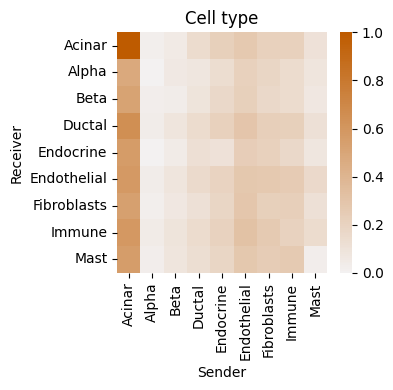

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['cell_type_coarse']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sliding_window_assignment']):

		mask = result.obs['sliding_window_assignment'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'Cell type')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/cosmx_GinterscalePCA_cell_type_coarse.csv')



plt.tight_layout()

## SCVI latent + Global (Transformer)

### Train

In [15]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [ ]:
cfg_path = 'config_files/melton_jimenez_25//InterScale_Cosmx_Nrec_globalSCVI.yaml'
model_type = 'GlobalModel'

In [17]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [18]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [19]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [20]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [24]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [25]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [26]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [27]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/cosmxnrecGSCVI_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [28]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/model/GlobalModel.py:105: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding, dtype=torch.float32, device=batch.x.device)


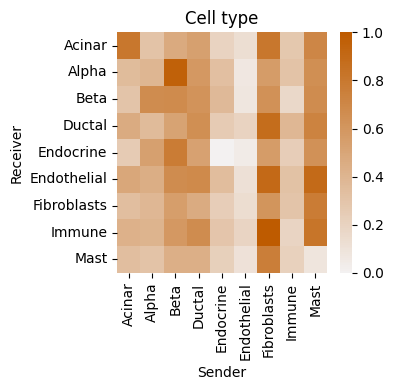

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['cell_type_coarse']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sliding_window_assignment']):

		mask = result.obs['sliding_window_assignment'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'Cell type')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/cosmx_GinterscaleSCVI_cell_type_coarse.csv')



plt.tight_layout()

## CellCharter latent + Global (Transformer)

### Train

In [6]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assign

In [ ]:
cfg_path = 'config_files/melton_jimenez_25//InterScale_Cosmx_Nrec_globalCellCharter.yaml'
model_type = 'GlobalModel'

In [8]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [ ]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [ ]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [9]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [10]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [11]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [12]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/cosmxnrecGCc_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [13]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/model/GlobalModel.py:105: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding, dtype=torch.float32, device=batch.x.device)


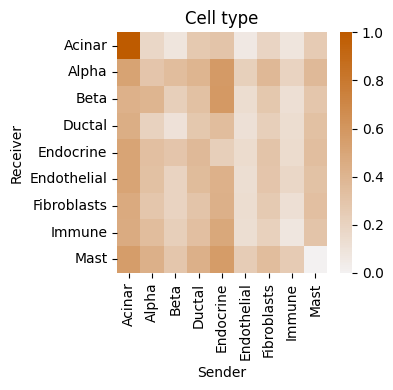

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['cell_type_coarse']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sliding_window_assignment']):

		mask = result.obs['sliding_window_assignment'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'Cell type')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/cosmx_GinterscaleCellCharter_cell_type_coarse.csv')



plt.tight_layout()

## Banksy latent + Global (Transformer)

### Train

In [ ]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assign

In [ ]:
cfg_path = 'config_files/melton_jimenez_25//InterScale_Cosmx_Nrec_globalBanksy.yaml'
model_type = 'GlobalModel'

In [ ]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [ ]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [ ]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [ ]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [ ]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [ ]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [ ]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/cosmxnrecGCc_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [ ]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/model/GlobalModel.py:105: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding, dtype=torch.float32, device=batch.x.device)


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['cell_type_coarse']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sliding_window_assignment']):

		mask = result.obs['sliding_window_assignment'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'Cell type')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/cosmx_GinterscaleBanksy_cell_type_coarse.csv')



plt.tight_layout()

## STAGATE latent + Global (Transformer)

### Train

In [ ]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assign

In [ ]:
cfg_path = 'config_files/melton_jimenez_25//InterScale_Cosmx_Nrec_globalSTAGATE.yaml'
model_type = 'GlobalModel'

In [ ]:
cfg = load_config(cfg_path)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


Nr. of zero expression cells: 0


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [ ]:
adata.obsp['adjacency_matrix_connectivities']=adata.obsp['spatial_connectivities']

In [ ]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)


dm = GraphAnnDataModule(datas=pyg_data_list, 
						num_workers=10,
						batch_size=int(cfg.dataset.batch_size), 
						pct_mask_nodes=cfg.dataset.pct_mask_nodes,
						learning_type="node")


Split key split already exists in adata.obs


In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

model = interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model.train(max_epochs = 40, 
           datamodule = dm,
           early_stopping = True,
		   enable_progress_bar=True,
           wandb_use = False)

### Evaluate

In [ ]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [ ]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

Nr. of zero expression cells: 0


In [ ]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [ ]:
model= interscale.model.GlobalModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path='model',global_component=True,local_component=True)

Loading model from model/cosmxnrecGCc_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [ ]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/model/GlobalModel.py:105: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding = torch.tensor(embedding, dtype=torch.float32, device=batch.x.device)


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for ix,c in enumerate(['cell_type_coarse']):

	attn_mxs = {}


	for sample in np.unique(result.obs['sliding_window_assignment']):

		mask = result.obs['sliding_window_assignment'] == sample

		attn_matrix = result.obsm['_attn_matrix'][mask]
		labels = result.obs[c][mask].values
		

		if attn_matrix.dtype == 'O':

			df_temp = pd.DataFrame(attn_matrix)
			df_numeric = df_temp.apply(pd.to_numeric, errors='coerce')

			valid_cols = ~df_numeric.isna().all(axis=0)
			attn_matrix_cleaned = df_numeric.loc[:, valid_cols].values

			del df_temp, df_numeric
		else:
			attn_matrix_cleaned = np.array(attn_matrix, dtype=float)
		np.fill_diagonal(attn_matrix_cleaned,0)

		aggregated_matrix_df = aggregate_attention_matrix_optimized(attn_matrix_cleaned, labels)
		attn_mxs[sample] = aggregated_matrix_df
		

		del attn_matrix, attn_matrix_cleaned


	average_attention_matrix = aggregate_attention_matrices(attn_mxs)


	if average_attention_matrix is not None:
		min_val = average_attention_matrix.min().min()
		max_val = average_attention_matrix.max().max()
		if max_val != min_val:
			norm_matrix = (average_attention_matrix - min_val) / (max_val - min_val)
		else:
			norm_matrix = average_attention_matrix

		clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)
	average_attention_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

	clean_matrix = norm_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(clean_matrix, cmap=map,center=0)
	plt.title(f'Cell type')
	plt.xlabel('Sender')
	plt.ylabel('Receiver')


	clean_matrix.to_csv(f'results/cosmx_GinterscaleSTAGATE_cell_type_coarse.csv')



plt.tight_layout()

# Steamboat

## Setup

In [1]:
import os
INTERSCALE_DIR = '/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility'
print(INTERSCALE_DIR)
os.chdir(INTERSCALE_DIR)

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility


In [2]:
import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

In [3]:
import torch
import scanpy as sc
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("sftw/Steamboat")
import steamboat as sf # "sf" = "Steamboat Factorization"
import steamboat.tools
import squidpy as sq


## Prepare data

In [ ]:
adata=sc.read_h5ad('data/melton_jimenez_25/cosmx_pancreas_s1.h5ad')
adata.obs['fov']
adata.X=adata.layers['counts']

In [6]:
adatas=[]

for i in adata.obs['fov'].unique():
    temp = adata[adata.obs['fov'] == i].copy()
    if temp.shape[0] < 100:
        print(f"Skipping FOV {i} with {temp.shape[0]} cells")
        continue
    adatas.append(temp)
    adatas[-1].obs['global'] = 0

In [7]:
adatas = sf.prep_adatas(adatas, norm=True, log1p=True, scale=False, renorm=False)

100%|██████████| 23/23 [00:00<00:00, 41.67it/s]


In [8]:
for i in range(len(adatas)):
	sq.gr.spatial_neighbors(adatas[i], n_neighs=8)

In [9]:
for i in range(len(adatas)):
	connectivity_matrix = adatas[i].obsp['spatial_connectivities']
	neighbor_counts = np.array(connectivity_matrix.sum(axis=1)).flatten()

	mask = neighbor_counts > 0

	adatas[i] = adatas[i][mask].copy()

In [10]:
for i in range(len(adatas)):
	adj_matrix = adatas[i].obsp['spatial_connectivities'].tocsr()
	adj_matrix_sym = adj_matrix + adj_matrix.T
	adj_matrix_sym[adj_matrix_sym > 1] = 1 # Forza i valori a 1
	adatas[i].obsp['spatial_connectivities'] = adj_matrix_sym

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
dataset = sf.make_dataset(adatas,sparse_graph=True,regional_obs=['global'])

Using ['global'] as regional annotations.


100%|██████████| 23/23 [00:01<00:00, 16.34it/s]

Not all cells in the following samples have the same number of neighbors:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22.
Steamboat can handle this. You can safely ignore this warning if this is expected.


## Prepare Model

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
n_heads = 10

sf.set_random_seed(0)
model = sf.Steamboat(adatas[0].var_names.tolist(), n_heads=n_heads, n_scales=3)
model = model.to(device)


In [26]:
cuda_dataset=dataset.to('cuda')

In [ ]:

import gc
import time

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()
    
ram_start_train = get_ram_mb()
t_train_start = time.perf_counter()


model.fit(cuda_dataset, entry_masking_rate=0.1, feature_masking_rate=0.0,
          max_epoch=5000, 
          loss_fun=torch.nn.MSELoss(reduction='sum'),
          opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=1e-3, report_per=200, stop_tol=200, device=device)

if device.type == "cuda":
    torch.cuda.synchronize()

t_train_end = time.perf_counter()

# Calcolo metriche Training
train_runtime_sec = t_train_end - t_train_start
train_vram_peak_gb = (
    (torch.cuda.max_memory_allocated(device) / (1024**3))
    if device.type == "cuda"
    else 0
)
train_ram_peak_gb = max(ram_start_train, get_ram_mb()) / 1024

In [ ]:
torch.save(model.state_dict(), 'model/steamboat_cosmx_model.pth')

## Evaluate

In [15]:
model.load_state_dict(torch.load('model/steamboat_cosmex_model.pth', map_location='cpu'))


<All keys matched successfully>

In [ ]:

all_adata=sc.read_h5ad('data/melton_jimenez_25/cosmx_pancreas_s1.h5ad')

In [17]:
indexes=[]

for i in range(len(adatas)):
	index=adatas[i].obs.index.to_list()
	indexes.extend(index)

all_adata=all_adata[indexes,:].copy()

In [18]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True,device=device)
sf.tools.gather_obs(all_adata, adatas)

100%|██████████| 23/23 [00:01<00:00, 19.74it/s]


AnnData object with n_obs × n_vars = 104658 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'niche_label', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window'
    uns: 'cell_type_coarse_colors', 'sliding_window_1_colors', 'sliding_window_2_colors', 'spatial', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_fov', 'q', 'local_k', 'ego_attn', 'local_attn', 'global_attn', 'attn

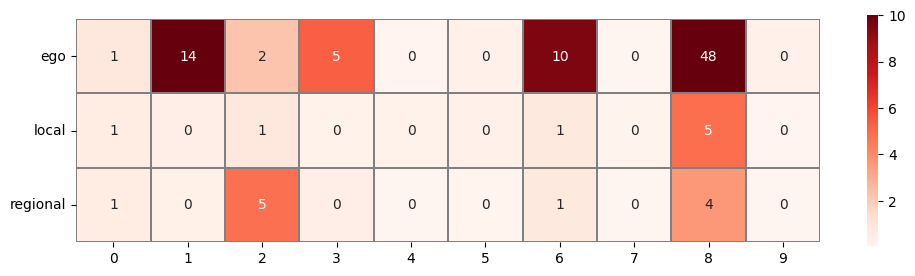

In [19]:
head_weights = sf.tools.calc_head_weights(adatas, model)
sf.tools.plot_head_weights(head_weights,figsize=(12,3))

In [ ]:
from sklearn.preprocessing import normalize
from scipy.sparse import issparse

X_orig = all_adata.X
X_recon = all_adata.obsm['X_recon']


X_orig_norm = normalize(X_orig, axis=1)
X_recon_norm = normalize(X_recon, axis=1)


if issparse(X_orig_norm):
    row_wise_similarities = np.array(X_orig_norm.multiply(X_recon_norm).sum(axis=1)).ravel()
else:
    row_wise_similarities = np.sum(X_orig_norm * X_recon_norm, axis=1)

mean_cosine_similarity = float(np.mean(row_wise_similarities))


In [ ]:
res_df = pd.DataFrame(
		[
			{
				"model": "Steamboat",
				"dataset": "melton_jimenez_25",
				"cell": adata.n_obs,
				"train_runtime_sec": train_runtime_sec,
				"train_vram_peak_gb": train_vram_peak_gb,
				"train_ram_peak_gb": train_ram_peak_gb,
				"cosine_sim":mean_cosine_similarity
			}
		]
	)

res_df.to_csv("results_seeds/S_meltonjimenez25_metrics_seed_n.csv", index=False)

In [20]:
result=all_adata.copy()

In [21]:
result.obsm['global_attn_0'] =result.obsm['global_attn']

### Global attention

In [22]:
def compute_full_attention_in_chunks(q, k, chunk_size=1000):
    """
    Compute full N x N attention matrix in chunks to avoid OOM.
    
    :param q: Query matrix (N, D)
    :param k: Key matrix (N, D)
    :param chunk_size: Number of rows to process at once
    """
    n_cells = q.shape[0]
    d_k = q.shape[-1]
    
    # Pre-allocate the full matrix only if you have enough RAM
    # If N=50k, this WILL still use ~10GB. 
    # If you don't have it, you should process and save to disk (memmap)
    attn_matrix = np.zeros((n_cells, n_cells), dtype=np.float32)
    
    k_t = k.T / np.sqrt(d_k)
    
    for i in range(0, n_cells, chunk_size):
        end = min(i + chunk_size, n_cells)
        
        # 1. Compute logits for the chunk: (chunk_size, N)
        logits_chunk = np.dot(q[i:end], k_t)
        
        # 2. Numerical stability: subtract max of the row
        max_val = np.max(logits_chunk, axis=1, keepdims=True)
        e_x = np.exp(logits_chunk - max_val)
        
        # 3. Compute Softmax for the chunk
        attn_matrix[i:end] = e_x / np.sum(e_x, axis=1, keepdims=True)
        
    return attn_matrix

In [ ]:
attn_matrix = compute_full_attention_in_chunks(result.obsm['q'], result.obsm['global_k_0'])

In [ ]:
df = pd.DataFrame(attn_matrix, index=result.obs['cell_type_coarse'], columns=result.obs['cell_type_coarse'])
row_grouped = df.groupby(level=0).mean()
cluster_attn_df = row_grouped.groupby(level=0, axis=1).mean()

In [ ]:
cluster_attn_df.to_csv('results/cosmx_GSteamboat_cell_type_coarse.csv')

### Local attention

In [ ]:
attn_matrix = compute_full_attention_in_chunks(result.obsm['q'], result.obsm['local_k'])

In [ ]:
df = pd.DataFrame(attn_matrix, index=result.obs['cell_type_coarse'], columns=result.obs['cell_type_coarse'])
row_grouped = df.groupby(level=0).mean()
cluster_attn_df = row_grouped.groupby(level=0, axis=1).mean()

In [ ]:
cluster_attn_df.to_csv('results/cosmx_LSteamboat_cell_type_coarse.csv')

# Amici

## Setup

In [1]:
import os
INTERSCALE_DIR = '/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility'
print(INTERSCALE_DIR)
os.chdir(INTERSCALE_DIR)

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/InterScale_reproducibility


In [2]:
import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

In [3]:
import torch
import scanpy as sc
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import matplotlib.pyplot as plt

from amici import AMICI
from amici.callbacks import AttentionPenaltyMonitor
from amici.interpretation import (
    AMICICounterfactualAttentionModule,
    AMICIAttentionModule,
    AMICIAblationModule,
)

## Prepare data

In [ ]:
adata=sc.read_h5ad('data/melton_jimenez_25/cosmx_pancreas_s1.h5ad')


In [5]:
mx=max(adata.obsm['spatial'][:,0])
my=max(adata.obsm['spatial'][:,1])

In [6]:
i=3
print(i//3)
print(i%3)

1
0


In [7]:
correction_mapx={}
correction_mapy={}

for i,l in enumerate(adata.obs['fov'].unique()):
	correction_mapx[l]=3*(i//3)*mx
	correction_mapy[l]=3*(i%3)*my


In [8]:
correction_x=adata.obs['fov'].map(correction_mapx)
correction_array = np.array(correction_x, dtype=float)
adata.obsm['spatial'][:,0]=adata.obsm['spatial'][:,0]+correction_array


correction_y=adata.obs['fov'].map(correction_mapy)
correction_arrayy = np.array(correction_y, dtype=float)
adata.obsm['spatial'][:,1]=adata.obsm['spatial'][:,1]+correction_arrayy

In [9]:
adata_train = adata[adata.obs['fov'].astype(int)<22]
adata_test = adata[adata.obs['fov'].astype(int)>21]

In [10]:
adata_test.obs['fov'].cat.categories.values

array(['22', '23', '24'], dtype=object)

## Setup model

In [11]:
# Set up the seed for reproducibility
seed = 42
pl.seed_everything(seed)

penalty_schedule_params = {
    "start_val": 1e-6,
    "end_val": 1e-3,
    "epoch_start": 10,
    "epoch_end": 30,
    "flavor": "linear",
}
model_params = {
    "n_heads": 8,
    "n_query_dim": 128,
    "n_head_size": 32,
    "n_nn_embed": 256,
    "n_nn_embed_hidden": 512,
    "attention_dummy_score": 3.0,
    "neighbor_dropout": 0.1,
    "attention_penalty_coef": penalty_schedule_params[
        "start_val"
    ],
    "value_l1_penalty_coef": 1e-5,
}
exp_params = {
    "lr": 1e-3,
    "epochs": 400,
    "batch_size": 512,
    "early_stopping": True,
    "early_stopping_monitor": "elbo_validation",
    "early_stopping_patience": 20,
    "learning_rate_monitor": True,
    "n_neighbors": 50,
}

[rank: 0] Seed set to 42


In [12]:
AMICI.setup_anndata(
    adata_train,
    labels_key="cell_type_coarse",
    coord_obsm_key="spatial",
    n_neighbors=exp_params["n_neighbors"],
)
model = AMICI(adata_train, **model_params)

INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [13]:
model_path = os.path.join(
    "model/",
    f"cosmex_{seed}_params",
)

plan_kwargs = {}
if "lr" in exp_params:
    plan_kwargs["lr"] = exp_params["lr"]

In [ ]:
model.train(
    max_epochs=int(exp_params.get("epochs")),
    batch_size=int(exp_params.get("batch_size")),
    plan_kwargs=plan_kwargs,
    early_stopping=exp_params.get("early_stopping"),
    early_stopping_monitor=exp_params.get("early_stopping_monitor"),
    early_stopping_patience=exp_params.get("early_stopping_patience"),
    check_val_every_n_epoch=1,
    callbacks=[
        AttentionPenaltyMonitor(
            **penalty_schedule_params
        ),
    ],
)

### Train

In [ ]:
model.save(model_path, overwrite=True)

### Evaluate

In [14]:
model= AMICI.load(model_path, adata)

INFO     File model/cosmex_42_params/model.pt already downloaded                                                   


In [ ]:

adata_residuals=model.get_neighbor_ablation_scores(
        adata=adata,
        compute_z_value=True,
    )

INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [ ]:
adata_residuals.save_object(f'data/melton_jimenez_25/cosmx_residuals_amici.pkl')

In [ ]:
ablation_residuals=AMICIAblationModule.load_object(f'data/melton_jimenez_25/cosmx_residuals_amici.pkl')

Text(50.72222222222221, 0.5, 'Receiver')

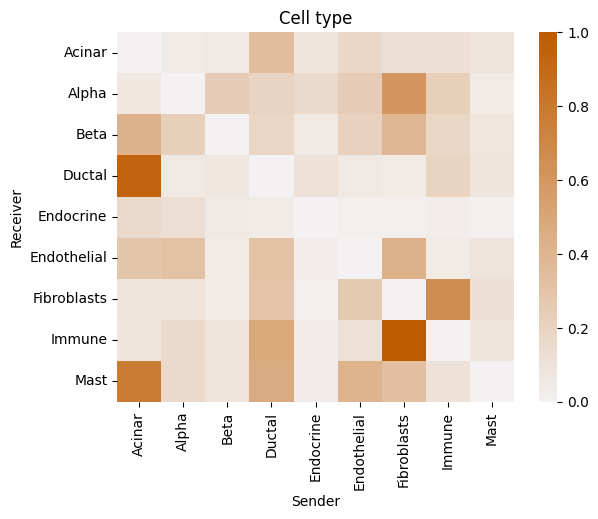

In [17]:
ablation_residuals._get_interaction_weight_matrix()


#df_scaled = ablation_residuals._get_interaction_weight_matrix().apply(lambda x: (x - x.mean()) / x.std(), axis=0)

cluster_attn_df = ablation_residuals._get_interaction_weight_matrix()
df_scaled= (cluster_attn_df - cluster_attn_df.min().min()) / (cluster_attn_df.max().max() - cluster_attn_df.min().min())

# Convert index and columns to integers for sorting
sorted_index = sorted(df_scaled.index, key=str)
sorted_columns = sorted(df_scaled.columns, key=str)

# Reindex the dataframe
df_scaled = df_scaled.loc[sorted_index, sorted_columns]

map=sns.diverging_palette(180,29,s=100, as_cmap=True)
sns.heatmap(df_scaled,cmap=map, center=0)
plt.title('Cell type')
plt.xlabel('Sender')
plt.ylabel('Receiver')

In [18]:
df_scaled.to_csv('results/cosmx_amici_cell_type_coarse.csv')

# Compare

In [19]:
from scipy.stats import pearsonr

In [20]:
def compute_approach_correlation(dfs_dict):
    """
    Calculate Pearson correlation between different attention matrices.
    
    Parameters:
    -----------
    dfs_dict : dict
        Dictionary {approach_name: dataframe [n_cluster x n_cluster]}
    """
    approach_names = list(dfs_dict.keys())
    n_approaches = len(approach_names)
    
    # Initialize an empty matrix for correlations
    corr_matrix = pd.DataFrame(np.zeros((n_approaches, n_approaches)), 
                               index=approach_names, 
                               columns=approach_names)
    
    # Flatten matrices and calculate Pearson
    for i, name1 in enumerate(approach_names):
        for j, name2 in enumerate(approach_names):
            # Flatten the DataFrames to 1D arrays
            vec1 = dfs_dict[name1].values.flatten()
            vec2 = dfs_dict[name2].values.flatten()
            
            # Calculate correlation coefficient
            corr, _ = pearsonr(vec1, vec2)
            corr_matrix.loc[name1, name2] = corr
            
    return corr_matrix

def reset_diagonal_to_zero(dfs_dict):
    """
    Set the diagonal of all attention DataFrames to zero.
    
    Parameters:
    -----------
    dfs_dict : dict
        Dictionary {approach_name: dataframe [n_cluster x n_cluster]}
    """
    for name, df in dfs_dict.items():
        # Using numpy.fill_diagonal is the most efficient way to modify the diagonal in-place
        # We access the underlying values of the DataFrame
        np.fill_diagonal(df.values, 0)
        
        # English comment: Optional - ensuring the DataFrame is returned to a consistent state
        # though np.fill_diagonal works in-place on the underlying numpy array.
        
    print("Diagonal values set to 0 for all dataframes.")

In [ ]:
models=["amici","DinterscaleGCN","GinterscalePCA","GinterscaleSCVI","GinterscaleCellCharter","GinterscaleBanksy","GinterscaleStagate","GSteamboat","LSteamboat"]
models_name=["Amici","interscale Dual - GCN","interscale Global - PCA","interscale Global - SCVI","interscale Global - CellCharter","interscale Global - Banksy","interscale Global - STAGATE","Steamboat Global","Steamboat Local"]

dfs_dict_name = {}
for ix,model in enumerate(models):
	dfs_dict_name[models[ix]]=models_name[ix]

dfs_dict_name

{'amici': 'Amici',
 'DinterscaleGCN': 'interscale Dual - GCN',
 'GinterscalePCA': 'interscale Global - PCA',
 'GinterscaleSCVI': 'interscale Global - SCVI',
 'GinterscaleCellCharter': 'interscale Global - CellCharter',
 'GinterscaleBanksy': 'interscale Global - Banksy',
 'GinterscaleStagate': 'interscale Global - STAGATE',
 'GSteamboat': 'Steamboat Global',
 'LSteamboat': 'Steamboat Local'}

Diagonal values set to 0 for all dataframes.


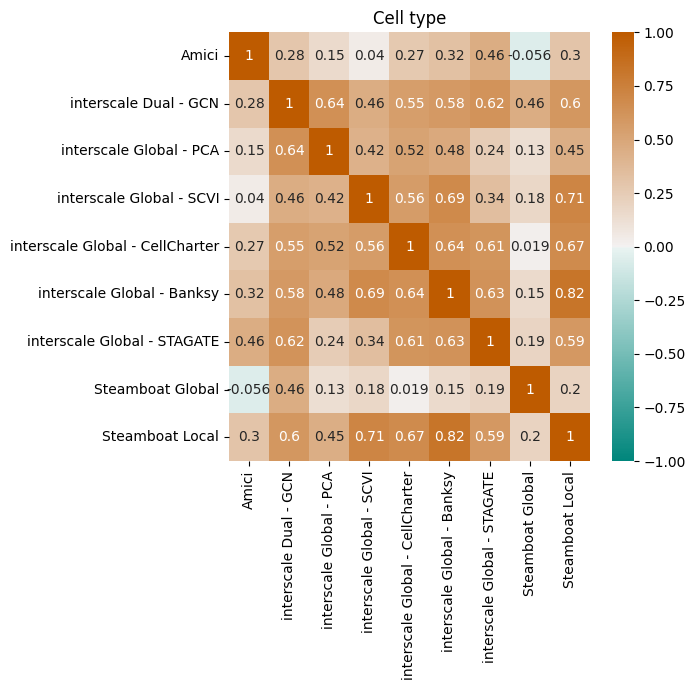

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

for ix,c in enumerate(['cell_type_coarse']):
	dfs_dict = {}
	for jx,a in enumerate(["amici","DinterscaleGCN","GinterscalePCA","GinterscaleSCVI","GinterscaleCellCharter","GinterscaleBanksy","GinterscaleStagate","GSteamboat","LSteamboat"]):
		d=pd.read_csv(f'INTERACTION/Benchmark/cosmx_{a}_{c}.csv',index_col=0)
		dfs_dict[dfs_dict_name[a]]=d
	reset_diagonal_to_zero(dfs_dict)
	corr_matrix=compute_approach_correlation(dfs_dict)
	corr_matrix=corr_matrix.round(3)
	map=sns.diverging_palette(180,29,s=100, as_cmap=True)
	sns.heatmap(corr_matrix, annot=True, cmap=map, vmin=-1, vmax=1)
	plt.title(f"Cell type")

plt.tight_layout()

